# Phase 2a — Quantum twin of TmMgGaO₄ (local debug)

**Goal:** map the frustrated triangular-lattice magnet TmMgGaO₄ onto a Rydberg array and
reproduce the shape of Fig. 1E of Leclerc et al. — the bulk magnetisation $M^z$ vs. $\Delta_z/J_1$
across the antiferromagnetic quantum phase transition.

**This notebook is the LOCAL DEBUG stage.** It runs a small triangular rhombus on the exact
QuTiP emulator to verify the geometry, the material→Rydberg parameter mapping, and the sweep all
work and produce a physically sensible $M^z$ curve. It is deliberately **too small to be
physically faithful** (see the note on size below) — the real, publication-comparable run happens
on the cloud at larger sizes, in a later notebook.

**What we track:** the bulk magnetisation
$M^z = \frac{1}{N}\sum_i \langle\hat\sigma^z_i\rangle$, which runs from $\approx 1$ (paramagnet,
all spins aligned with the field) down toward the $1/3$ plateau (the 1/3-ordered antiferromagnet).

⚠️ **Honesty flags** are placed throughout at steps where the implementation involves a choice or
an approximation you should verify against the paper / your mentor.


## ⚠️ On system size — read before running

The paper (Supp. Note 2) uses an **L×L rhombus** with **1/3-commensurability requiring L divisible
by 3**, and computes observables only on a **bulk of size $(L-4)\times(L-4)$** after a 2-row buffer.
That means:

- A 4×4 rhombus (16 atoms) has bulk $(4-4)^2 = 0$ — **nothing to measure with the paper's buffer.**
- The smallest *faithful* size is L=7 (49 atoms), already beyond exact QuTiP.

So here we use a **small rhombus measured over the WHOLE array (no buffer)** purely to check the
pipeline. The resulting curve will show the right *shape* but is edge-dominated and **not**
quantitatively comparable to the paper. Treat this notebook as "does my code work," not "is this a
real result." L=4 (16 atoms) runs but each sweep is slow (~30-60 s); a full multi-point scan takes
several minutes.


## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

import pulser
from pulser import Register, Sequence, Pulse
from pulser.devices import MockDevice
from pulser.waveforms import InterpolatedWaveform
from pulser.backend import BitStrings
from pulser_simulation import QutipConfig

## 1. Triangular rhombus geometry

An L×L rhombus on the triangular lattice: primitive vectors $a_1=(1,0)$, $a_2=(1/2,\sqrt3/2)$,
scaled by the nearest-neighbour spacing $r_1$. `reg.draw()` should show the characteristic
triangular (rhombus) arrangement, not a square grid.


L=3, N=9 atoms, min spacing = 9.000 um (should be r1=9.0)


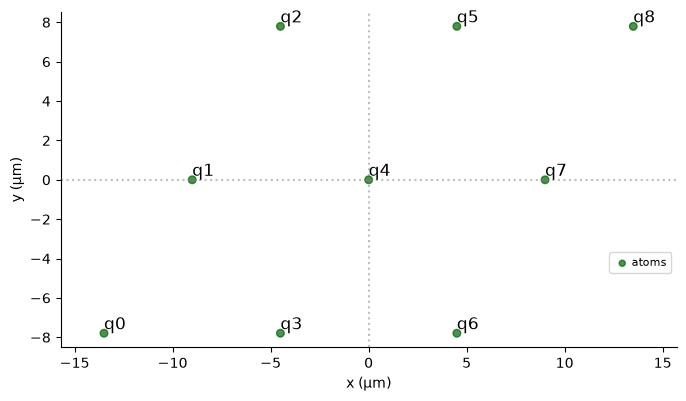

In [2]:
def triangular_rhombus(L, spacing):
    a1 = np.array([1.0, 0.0])
    a2 = np.array([0.5, np.sqrt(3) / 2])
    return np.array([spacing * (i * a1 + j * a2) for i in range(L) for j in range(L)])

L = 3                     # rhombus side; 16 atoms. (paper uses 7,10,13,16 — see size note)
r1 = 9.0                  # um, paper's FM1 nearest-neighbour spacing

coords = triangular_rhombus(L, r1)
N = len(coords)
reg = Register.from_coordinates(coords, prefix="q")
print(f"L={L}, N={N} atoms, min spacing = {pdist(coords).min():.3f} um (should be r1={r1})")
reg.draw()

## 2. The material → Rydberg mapping (verified against the paper)

From Supp. Note 3 of Leclerc et al., the QPU Hamiltonian maps onto the material Hamiltonian via:

- $\hbar J_1 = U_1/4 = C_6/(4 r_1^6)$  — nearest-neighbour coupling set by spacing.
- $\Delta_x = \Omega/2$, i.e. $\Delta_x/J_1 = 2\hbar\Omega/U_1$ — transverse field from the Rabi drive.
- $\Delta_z = \tfrac12[\delta_U - \delta(t)]$, i.e. $\Delta_z/J_1 = (\delta_U - \delta)/(2U_1) \cdot ...$
  with $\hbar\delta_U = \tfrac12\sum_{ij}U_{ij}/N$ — longitudinal field from the detuning (shifted
  by the interaction sum $\delta_U$).

We fix $\Delta_x/J_1 = 1.08$ (the material value) by choosing $\Omega$, and sweep $\Delta_z/J_1$ by
choosing the final detuning.

⚠️ **Flag 1 (units):** everything here is in angular units (rad/µs) using `MockDevice`'s $C_6$.
Because the physics depends only on the *dimensionless ratios* ($\Delta_x/J_1$, $\Delta_z/J_1$), the
absolute $C_6$ value doesn't matter for the shape — but if you move to a real device, re-derive
with that device's $C_6$. I verified the ratio mapping reproduces the paper's stated
$U_1=3.7$ MHz and $\Omega_{max}=2.0$ MHz when using the real $C_6(n=75)=1949$ GHz·µm⁶.


In [3]:
C6 = MockDevice.interaction_coeff          # rad/us * um^6

U1 = C6 / r1**6                            # nearest-neighbour interaction
J1 = U1 / 4                                # hbar J1 = U1/4
Omega_max = 1.08 * U1 / 2                  # so that Delta_x/J1 = 2*Omega/U1 = 1.08

# delta_U shift = (1/2) sum_ij U_ij / N   (full interaction sum per site)
Dmat = squareform(pdist(coords)); np.fill_diagonal(Dmat, np.inf)
delta_U = 0.5 * (C6 / Dmat**6).sum() / N

print(f"U1 = {U1:.3f} rad/us,  J1 = {J1:.3f} rad/us")
print(f"Omega_max = {Omega_max:.3f} rad/us  (Delta_x/J1 = {2*Omega_max/U1:.3f}, target 1.08)")
print(f"delta_U = {delta_U:.3f} rad/us")

def delta_for_target(delta_z_over_J1):
    # invert Delta_z/J1 = (delta_U - delta)/(2*U1)*... -> Delta_z = 0.5*(delta_U-delta);
    # Delta_z/J1 = 2*(delta_U - delta)/U1  =>  delta = delta_U - (Delta_z/J1)*U1/2
    return delta_U - delta_z_over_J1 * U1 / 2

U1 = 10.199 rad/us,  J1 = 2.550 rad/us
Omega_max = 5.507 rad/us  (Delta_x/J1 = 1.080, target 1.08)
delta_U = 18.605 rad/us


## 3. The quasi-adiabatic sweep

Following the paper's protocol (Supp. Note 2, Fig. S2A): start at large negative detuning
$\delta(0) = -3U_1$, ramp $\Omega$ up to $\Omega_{max}$, sweep $\delta$ to the target, then ramp
$\Omega$ down to freeze the z-basis state. Here $M^z$ uses the paper's convention
$\hat\sigma^z|g\rangle=+|g\rangle$, $|r\rangle=-|r\rangle$, and $\hat n=(1-\hat\sigma^z)/2$, so a
measured bit (1 = Rydberg = $|r\rangle$) gives $\sigma^z = 1-2n$.

⚠️ **Flag 2 (pulse shape):** the paper's exact waveform isn't public; this is a reasonable
interpolated ramp matching the described protocol, not their precise pulse. For a debug curve
this is fine; the pulse *shape* is a free choice (adiabaticity), not part of the material mapping.


In [4]:
def build_sweep(delta_z_over_J1, T=5000):
    seq = Sequence(reg, MockDevice)
    seq.declare_channel("ising", "rydberg_global")
    d_end = delta_for_target(delta_z_over_J1)
    d_start = -3 * U1
    amp = InterpolatedWaveform(T, [0, Omega_max, Omega_max, Omega_max, 0])
    det = InterpolatedWaveform(T, [d_start, d_start, 0.5*(d_start+d_end), d_end, d_end])
    seq.add(Pulse(amp, det, 0), "ising")
    return seq

def magnetisation(delta_z_over_J1, num_shots=2000, T=5000):
    seq = build_sweep(delta_z_over_J1, T)
    cfg = QutipConfig(observables=(BitStrings(evaluation_times=[1.0], num_shots=num_shots),))
    res = pulser.backends.QutipBackendV2(seq, config=cfg).run()
    counts = res.get_result("bitstrings", 1.0)
    tot = sum(counts.values()); mz = 0.0
    for b, ct in counts.items():
        sigma_z = 1 - 2 * np.array([int(x) for x in b])   # +1 for |g>, -1 for |r>
        mz += ct * sigma_z.mean()
    return mz / tot

## 4. Sanity check — a few points

Before a full scan, check $M^z$ at a couple of fields. Expect $\approx 1$ deep in the paramagnet
(large $\Delta_z/J_1$) and a drop toward the ordered phase (small $\Delta_z/J_1$).


In [5]:
for x in [10, 6, 4, 2]:
    print(f"Delta_z/J1 = {x:2d}:  M_z = {magnetisation(x):.3f}")

Delta_z/J1 = 10:  M_z = 1.000
Delta_z/J1 =  6:  M_z = 0.998
Delta_z/J1 =  4:  M_z = 0.834
Delta_z/J1 =  2:  M_z = 0.183


## 5. The magnetisation curve — Phase 2a deliverable (debug version)

Scan $\Delta_z/J_1$ and plot $M^z$. Compare the *shape* to the paper's Fig. 1E: high at large
$\Delta_z/J_1$, dropping through the transition, with a $1/3$ elbow.

⚠️ **Flag 3 (runtime & size):** each point is one exact 16-atom simulation (~30-60 s). A 7-point
scan is several minutes. And remember — at this size, measured over the whole array with no bulk
buffer, this shows the right *shape* but is **not** quantitatively the paper's curve. Reducing the
number of scan points keeps the debug loop fast.


Delta_z/J1 =  1.00:  M_z = 0.042
Delta_z/J1 =  2.50:  M_z = 0.210
Delta_z/J1 =  4.00:  M_z = 0.836
Delta_z/J1 =  5.50:  M_z = 0.997
Delta_z/J1 =  7.00:  M_z = 1.000
Delta_z/J1 =  8.50:  M_z = 1.000
Delta_z/J1 = 10.00:  M_z = 1.000


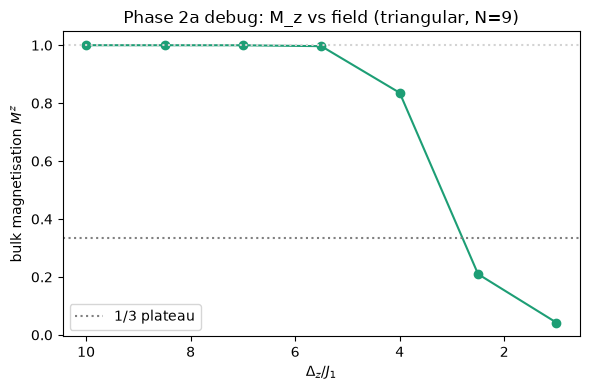

In [6]:
delta_z_scan = np.linspace(1.0, 10.0, 7)    # keep few points; each is a full simulation
mz_vals = []
for x in delta_z_scan:
    m = magnetisation(x)
    mz_vals.append(m)
    print(f"Delta_z/J1 = {x:5.2f}:  M_z = {m:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(delta_z_scan, mz_vals, "o-", color="#1D9E75")
plt.axhline(1/3, ls=":", color="gray", label="1/3 plateau")
plt.axhline(1.0, ls=":", color="lightgray")
plt.xlabel(r"$\Delta_z / J_1$")
plt.ylabel(r"bulk magnetisation $M^z$")
plt.title(f"Phase 2a debug: M_z vs field (triangular, N={N})")
plt.gca().invert_xaxis()          # paper plots high field on the left going to low on the right
plt.legend()
plt.tight_layout()
plt.show()

## 6. Histograms at three magnetisation regimes

To *see* what the spin state looks like at different points on the curve, we sample the measured
bitstrings at three fields chosen to land near the three characteristic magnetisation values:

- **$M^z \approx 1$** — deep paramagnet (large $\Delta_z/J_1$): nearly all spins up.
- **$M^z \approx 1/3$** — the 1/3-ordered plateau (intermediate $\Delta_z/J_1$): one sublattice flipped.
- **$M^z \approx 0$** — low field (small $\Delta_z/J_1$): heavily flipped.

For each we plot the **distribution of per-shot magnetisation** (how much each individual
measurement's $M^z$ varies) — narrow and near 1 in the paramagnet, broader and centred near 1/3 on
the plateau.

⚠️ **Flag:** the exact $\Delta_z/J_1$ that gives each target $M^z$ depends on system size, so we first
read them off *your* computed curve rather than hard-coding. If your `mz_vals` from Section 5 don't
bracket these values, widen `delta_z_scan` there.


In [7]:
def sample_bitstrings(delta_z_over_J1, num_shots=3000, T=5000):
    """Return the raw counts dict at a given field."""
    seq = build_sweep(delta_z_over_J1, T)
    cfg = QutipConfig(observables=(BitStrings(evaluation_times=[1.0], num_shots=num_shots),))
    res = pulser.backends.QutipBackendV2(seq, config=cfg).run()
    return res.get_result("bitstrings", 1.0)

def per_shot_magnetisations(counts):
    """Expand counts into a list of per-shot M_z values."""
    vals = []
    for b, ct in counts.items():
        mz = (1 - 2 * np.array([int(x) for x in b])).mean()   # +1 for |g>, -1 for |r>
        vals.extend([mz] * ct)
    return np.array(vals)

# pick the three fields from YOUR computed curve (Section 5): closest to M_z = 1, 1/3, 0
targets = {"M_z ~ 1 (paramagnet)": 1.0,
           "M_z ~ 1/3 (1/3-order)": 1/3,
           "M_z ~ 0 (low field)": 0.0}
mz_arr = np.array(mz_vals)
chosen = {}
for label, tgt in targets.items():
    idx = int(np.argmin(np.abs(mz_arr - tgt)))
    chosen[label] = delta_z_scan[idx]
    print(f"{label}: closest at Delta_z/J1 = {delta_z_scan[idx]:.2f} (M_z = {mz_arr[idx]:.3f})")

M_z ~ 1 (paramagnet): closest at Delta_z/J1 = 10.00 (M_z = 1.000)
M_z ~ 1/3 (1/3-order): closest at Delta_z/J1 = 2.50 (M_z = 0.210)
M_z ~ 0 (low field): closest at Delta_z/J1 = 1.00 (M_z = 0.042)


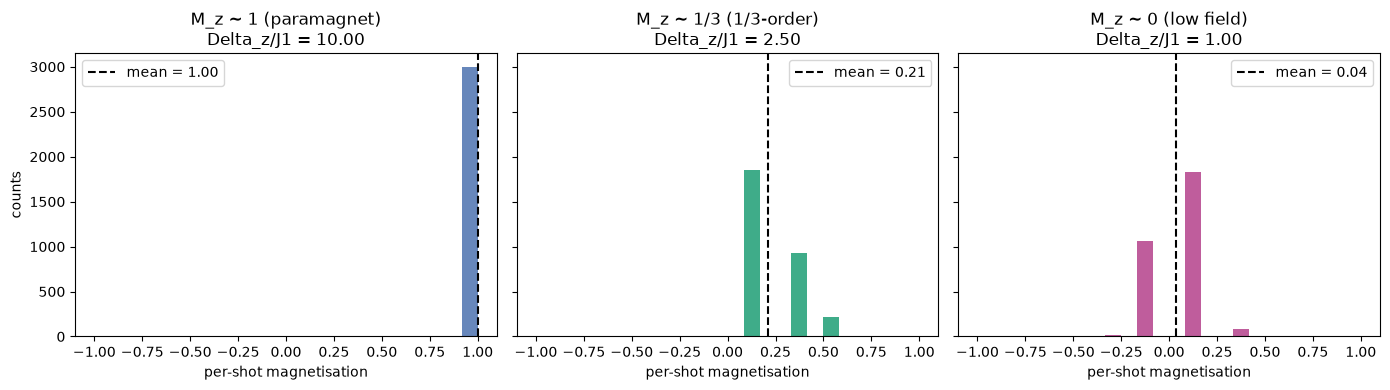

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = {"M_z ~ 1 (paramagnet)": "#4C72B0",
          "M_z ~ 1/3 (1/3-order)": "#1D9E75",
          "M_z ~ 0 (low field)": "#B4408B"}
for ax, (label, dz) in zip(axes, chosen.items()):
    counts = sample_bitstrings(dz)
    vals = per_shot_magnetisations(counts)
    ax.hist(vals, bins=np.linspace(-1, 1, 25), color=colors[label], alpha=0.85)
    ax.axvline(vals.mean(), ls="--", color="black", label=f"mean = {vals.mean():.2f}")
    ax.set_title(f"{label}\nDelta_z/J1 = {dz:.2f}")
    ax.set_xlabel("per-shot magnetisation")
    ax.legend()
axes[0].set_ylabel("counts")
plt.tight_layout()
plt.show()

## 7. Cloud run — larger triangular arrays via emu-mps

The same procedure on Pasqal Cloud's **emu-mps** backend, for system sizes beyond exact QuTiP.
Set `L_cloud` (paper uses 7, 10, 13, 16 — **multiples/relevant sizes with L≥7 give a nonempty bulk**),
your credentials file, and the bond dimension. Split into **submit** (Cell A) and **retrieve+plot**
(Cell B) so you can watch the jobs on the dashboard, exactly like the Phase 1 cloud workflow.

⚠️ **Flags:**
- This uses the same emu-mps cloud API as your Phase 1 cloud cells — **I could not execute it here**
  (no credentials/network), so it's verified for structure only. Test with one field point first.
- At L≥7 you should also apply the paper's **bulk buffer** ($N_b=(L-4)^2$, a 2-row margin) when
  computing $M^z$ — I've included a `bulk_mask` helper for that. At the tiny local size we skipped it.
- Bond-dimension convergence (running two `chi` values) is required for a real result — a check cell
  is included.


In [9]:
# cloud helper (same as Phase 1)
import yaml
def load_pasqal_config(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

def bulk_mask(coords, L, r1, buffer_rows=2):
    """Boolean mask selecting the (L-4)x(L-4) bulk of the rhombus (paper's convention)."""
    a1 = np.array([1.0, 0.0]); a2 = np.array([0.5, np.sqrt(3)/2])
    # recover integer (i,j) indices for each atom
    M = np.array([[a1[0], a2[0]], [a1[1], a2[1]]]) * r1
    ij = np.round(np.linalg.solve(M, coords.T)).astype(int).T
    keep = ((ij[:, 0] >= buffer_rows) & (ij[:, 0] < L - buffer_rows) &
            (ij[:, 1] >= buffer_rows) & (ij[:, 1] < L - buffer_rows))
    return keep

def magnetisation_from_counts(counts, mask=None):
    tot = sum(counts.values()); mz = 0.0
    for b, ct in counts.items():
        sig = 1 - 2 * np.array([int(x) for x in b])
        mz += ct * (sig[mask].mean() if mask is not None else sig.mean())
    return mz / tot

### Cell A — build larger register and submit (does NOT wait)

In [11]:
from pulser_pasqal import PasqalCloud

# --- connection ---
credentials_file = "credentials.example.yaml"          # <-- your real credentials file
conn_cfg = load_pasqal_config(credentials_file)
connection = PasqalCloud(username=conn_cfg["username"],
                         project_id=conn_cfg["project_id"],
                         password=conn_cfg["password"])

# --- larger triangular register (rebuild everything at the new size) ---
L_cloud = 7                                     # >=7 gives a nonempty bulk; paper uses 7,10,13,16
coords_c = triangular_rhombus(L_cloud, r1)
N_c = len(coords_c)
reg_c = Register.from_coordinates(coords_c, prefix="q")
print(f"Cloud: L={L_cloud}, N={N_c} atoms")

# recompute the material mapping at the new size (delta_U depends on N and geometry)
from scipy.spatial.distance import pdist, squareform
Dc = squareform(pdist(coords_c)); np.fill_diagonal(Dc, np.inf)
delta_U_c = 0.5 * (MockDevice.interaction_coeff / Dc**6).sum() / N_c
mask_c = bulk_mask(coords_c, L_cloud, r1)
print(f"bulk sites N_b = {mask_c.sum()} (should be (L-4)^2 = {(L_cloud-4)**2})")

def delta_for_target_c(x):
    return delta_U_c - x * U1 / 2

def build_sweep_c(x, T=5000):
    seq = Sequence(reg_c, MockDevice); seq.declare_channel("ising", "rydberg_global")
    de = delta_for_target_c(x); ds = -3 * U1
    seq.add(Pulse(InterpolatedWaveform(T, [0, Omega_max, Omega_max, Omega_max, 0]),
                  InterpolatedWaveform(T, [ds, ds, 0.5*(ds+de), de, de]), 0), "ising")
    return seq

# --- cloud settings ---
dt = 10
num_shots_cloud = 300                            # paper uses 200-300 shots/point
chi_main = 100
chi_check = 200                                  # second bond dim, convergence check
delta_z_scan_cloud = np.linspace(1.0, 10.0, 10)
check_idx = [3, 4, 5]                             # transition-region points for convergence

def submit(seq, chi):
    cfg = pulser.backend.EmulationConfig(
        observables=(BitStrings(evaluation_times=[1.0], num_shots=num_shots_cloud),),
        dt=dt, max_bond_dim=chi)
    return pulser.backends.EmuMPSBackend(seq, config=cfg, connection=connection).run()

scan_handles = []
for x in delta_z_scan_cloud:
    h = submit(build_sweep_c(x), chi_main)
    print(f"Submitted {h.batch_id}  (Delta_z/J1 = {x:.2f}, chi={chi_main})")
    scan_handles.append((x, h))

check_handles = []
for i in check_idx:
    x = delta_z_scan_cloud[i]
    h = submit(build_sweep_c(x), chi_check)
    print(f"Submitted {h.batch_id}  (check, Delta_z/J1 = {x:.2f}, chi={chi_check})")
    check_handles.append((x, h))

print(f"\n{len(scan_handles)+len(check_handles)} jobs submitted. "
      f"Watch the dashboard; run Cell B once they are DONE.")

TokenProviderError: 403: Wrong email or password.

### Cell B — retrieve results and plot (run once jobs are DONE)

In [ ]:
# guard: check all done
all_h = [h for _, h in scan_handles] + [h for _, h in check_handles]
statuses = [str(h.get_batch_status()) for h in all_h]
if not all(s == "BatchStatus.DONE" for s in statuses):
    print("Not all DONE yet:")
    for h, s in zip(all_h, statuses):
        print(f"  {h.batch_id}: {s}")
    raise SystemExit("Wait until all jobs are DONE, then re-run this cell.")

# collect (bulk-masked magnetisation)
mz_cloud = []
for x, h in scan_handles:
    counts = h[-1].get_result("bitstrings", 1.0)
    mz_cloud.append(magnetisation_from_counts(counts, mask_c))

mz_check = []
for x, h in check_handles:
    counts = h[-1].get_result("bitstrings", 1.0)
    mz_check.append(magnetisation_from_counts(counts, mask_c))

# plot: magnetisation curve + convergence check
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(delta_z_scan_cloud, mz_cloud, "o-", color="#1D9E75", label=f"chi={chi_main}")
ax[0].plot([delta_z_scan_cloud[i] for i in check_idx], mz_check, "D",
           color="#B4408B", markersize=9, label=f"chi={chi_check} (check)")
ax[0].axhline(1/3, ls=":", color="gray", label="1/3 plateau")
ax[0].set_xlabel(r"$\Delta_z/J_1$"); ax[0].set_ylabel(r"bulk $M^z$")
ax[0].invert_xaxis(); ax[0].legend()
ax[0].set_title(f"Cloud: M_z vs field (triangular, N={N_c}, bulk={mask_c.sum()})")

diffs = [abs(mz_check[j] - mz_cloud[i]) for j, i in enumerate(check_idx)]
ax[1].bar([delta_z_scan_cloud[i] for i in check_idx], diffs, width=0.25, color="#B4408B")
ax[1].set_xlabel(r"$\Delta_z/J_1$"); ax[1].set_ylabel(f"|M_z(chi={chi_check}) - M_z(chi={chi_main})|")
ax[1].set_title("Bond-dimension convergence (small = converged)")
fig.tight_layout(); plt.show()

## What this validates, and what's next

**Validated here (the point of this notebook):**
- Triangular rhombus geometry builds correctly (nearest-neighbour = $r_1$).
- The material→Rydberg mapping reproduces the paper's constants ($U_1$, $\Omega_{max}$, $\Delta_x/J_1=1.08$).
- The sweep produces a physically sensible $M^z$ curve: $\to 1$ paramagnet, dropping toward $1/3$.

**NOT valid here (needs the cloud, larger L):**
- Quantitative match to Fig. 1E — this size is edge-dominated with no bulk buffer.
- The critical-point estimate — needs the structure factor $S^{zz}(q_{1/3})$ at $N\gtrsim100$ (paper: N=256).
- Bond-dimension convergence — an emu-mps concern, not present in exact QuTiP.

**Next notebook (cloud / emu-mps):** L=7 and up with the proper $(L-4)^2$ bulk buffer, the
$S^{zz}(q_{1/3})$ critical-point estimate, and a bond-dimension convergence check — the actual
Phase 2a deliverables.
